<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-07-07 10:06:14--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  33.7MB/s    in 6.2s    

2026-07-07 10:06:21 (32.4 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install numpy

In [4]:
!pip install matplotlib

In [5]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [31]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [32]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [33]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [34]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


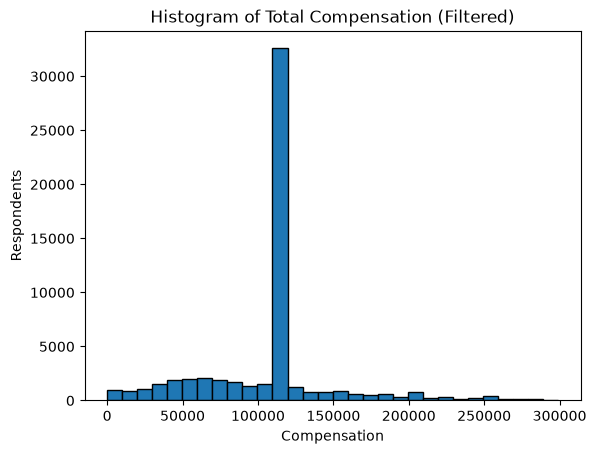

In [35]:
## Write your code here
Query = "SELECT * FROM main"
df = pd.read_sql_query(Query, conn)

#Separate column names by type
numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["str", "category"]).columns

#Create a single dictionary mapping each column to its fill value
fill_values = {}

for col in numeric_cols:
    fill_values[col] = df[col].median()

for col in categorical_cols:
    fill_values[col] = df[col].mode()[0]

#Fill all missing values at once
df = df.fillna(value=fill_values)

filtered_df = df[df['CompTotal'] < 300000]

filtered_df['CompTotal'].plot(kind='hist', bins=30, edgecolor='black')

plt.title('Histogram of Total Compensation (Filtered)')
plt.ylabel('Respondents')
plt.xlabel('Compensation')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [36]:
df['YearsCodePro'].unique()

<StringArray>
[                 '2',                 '17',                 '27',
                  '7',                 '11',                 '25',
                 '12',                 '10',                  '3',
   'Less than 1 year',                 '18',                 '37',
                 '15',                 '20',                  '6',
                 '16',                  '8',                 '14',
                  '4',                 '45',                  '1',
                 '24',                 '29',                  '5',
                 '30',                 '26',                  '9',
                 '33',                 '13',                 '35',
                 '23',                 '22',                 '31',
                 '19',                 '21',                 '28',
                 '34',                 '32',                 '40',
                 '50',                 '39',                 '44',
                 '42',                 '41',    

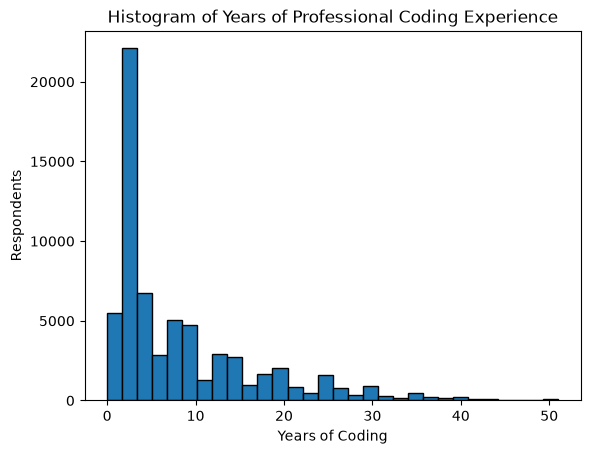

In [37]:
## Write your code here
#Replace text responses with numbers (common in Stack Overflow survey data)
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})

#Convert the column to numeric, turning any remaining unparseable text into NaN
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

df['YearsCodePro'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Histogram of Years of Professional Coding Experience')
plt.ylabel('Respondents')
plt.xlabel('Years of Coding')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


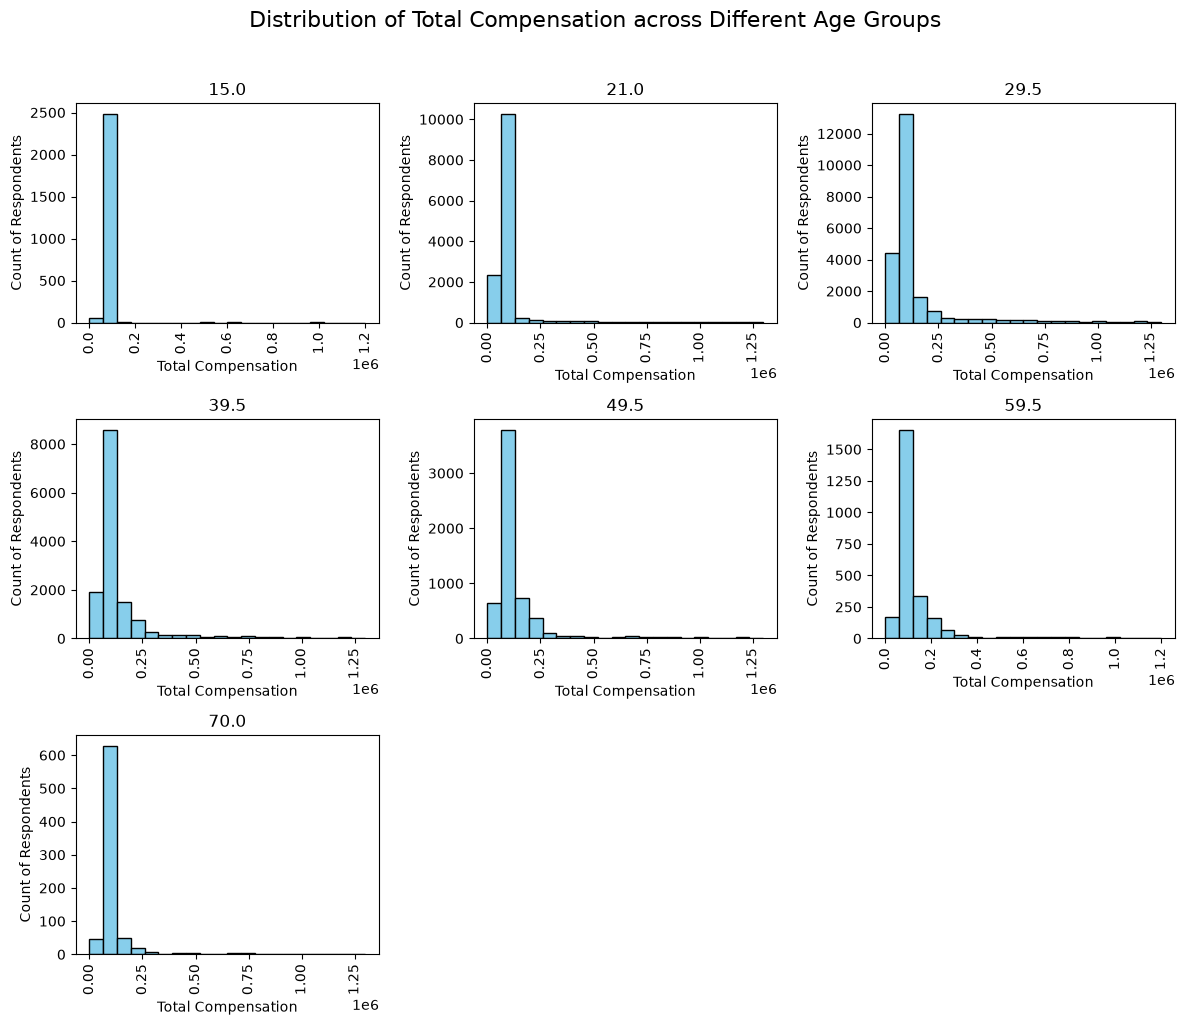

In [38]:
## Write your code here
# Define midpoints for the ranges
midpoint = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 70,
    "Prefer not to say": np.nan,
}

# Apply the mapping
df["Age"] = df["Age"].map(midpoint)
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")


analysis_df = df[["CompTotal", "Age"]].dropna()

# Filter extreme outliers (e.g., top 5%) so the histogram scale looks good
upper_limit = analysis_df["CompTotal"].quantile(0.95)
filtered_df = analysis_df[analysis_df["CompTotal"] <= upper_limit]

# Plot the grouped histograms
axes = filtered_df["CompTotal"].hist(
    by=filtered_df["Age"],
    bins=20,
    edgecolor="black",
    figsize=(12, 10),
    grid=False,
    color="skyblue",
)

# Set up the labels
plt.suptitle(
    "Distribution of Total Compensation across Different Age Groups",
    fontsize=16,
    y=1.02,
)
for ax in axes.flatten():
    ax.set_xlabel("Total Compensation")
    ax.set_ylabel("Count of Respondents")

plt.tight_layout()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


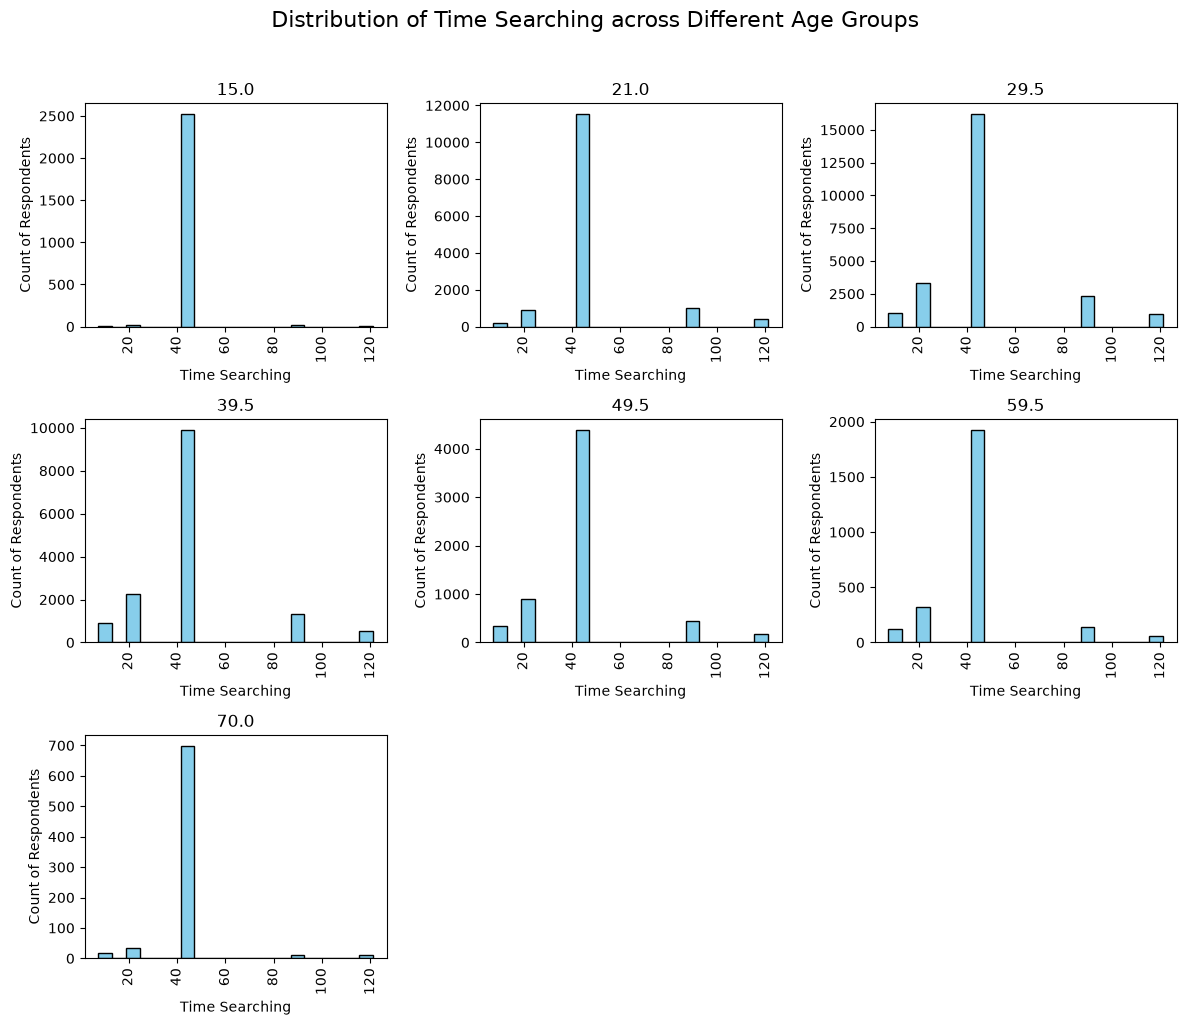

In [39]:
## Write your code here
df['TimeSearching'].unique()
time_mapping = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45.0,
    '60-120 minutes a day': 90.0,
    'Over 120 minutes a day': 121
}

#Apply the mapping to create a clean numeric column
df['TimeSearching'] = df['TimeSearching'].map(time_mapping)

axes = df["TimeSearching"].hist(
    by=df["Age"],
    bins=20,
    edgecolor="black",
    figsize=(12, 10),
    grid=False,
    color="skyblue",
)

# Set up the labels
plt.suptitle(
    "Distribution of Time Searching across Different Age Groups",
    fontsize=16,
    y=1.02,
)
for ax in axes.flatten():
    ax.set_xlabel("Time Searching")
    ax.set_ylabel("Count of Respondents")

plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


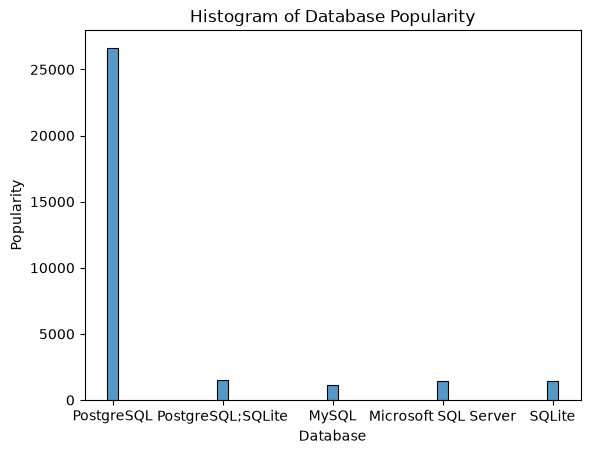

In [40]:
## Write your code here
#Split and explode columns if respondents selected multiple databases
#exploded_db = df["DatabaseWantToWorkWith"].dropna().str.split(";").explode()

top_5 = df['DatabaseWantToWorkWith'].value_counts().head().index
df_top_5 = df[df['DatabaseWantToWorkWith'].isin(top_5)]

sns.histplot(data=df_top_5, x='DatabaseWantToWorkWith', shrink=0.1)
plt.title("Histogram of Database Popularity")
plt.xlabel("Database")
plt.ylabel("Popularity")

plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [ ]:
## Write your code here
!pip install seaborn

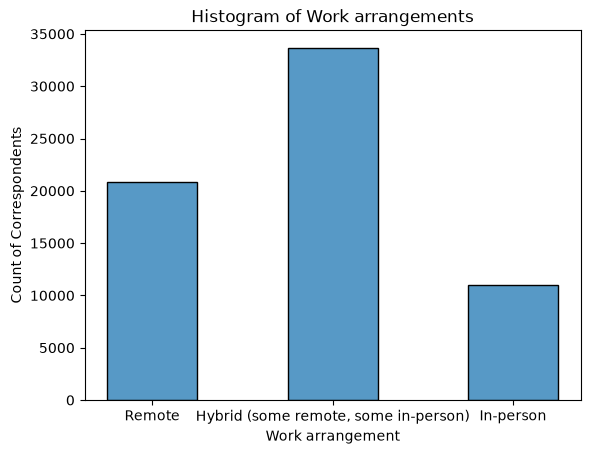

In [27]:
import seaborn as sns
sns.histplot(data=df, x='RemoteWork', shrink=0.5)
plt.title("Histogram of Work arrangements")
plt.xlabel("Work arrangement")
plt.ylabel("Count of Correspondents")
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


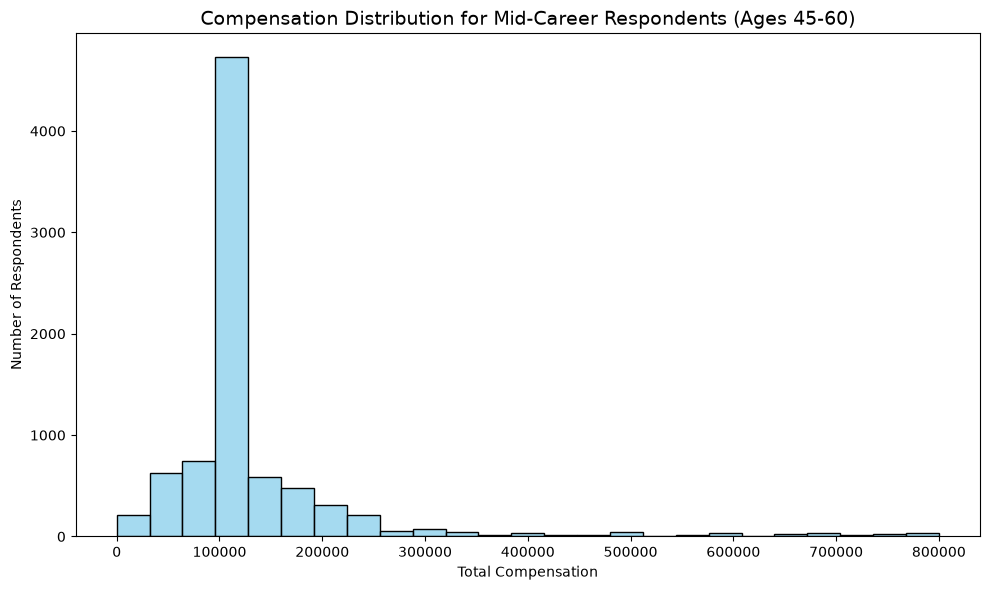

In [28]:
## Write your code here
mid_career_df = df[
    (df["Age"] >= 45) & (df["Age"] <= 60)
]

#Outlier check: Filter out extreme compensation entries (top 5%) for better binning
upper_limit = mid_career_df["CompTotal"].quantile(0.95)
filtered_mid_career = mid_career_df[
    mid_career_df["CompTotal"] <= upper_limit
]

plt.figure(figsize=(10, 6))
sns.histplot(
    data=filtered_mid_career,
    x="CompTotal",
    bins=25,
    color="skyblue",
    edgecolor="black",
)

plt.title(
    "Compensation Distribution for Mid-Career Respondents (Ages 45-60)",
    fontsize=14,
)
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


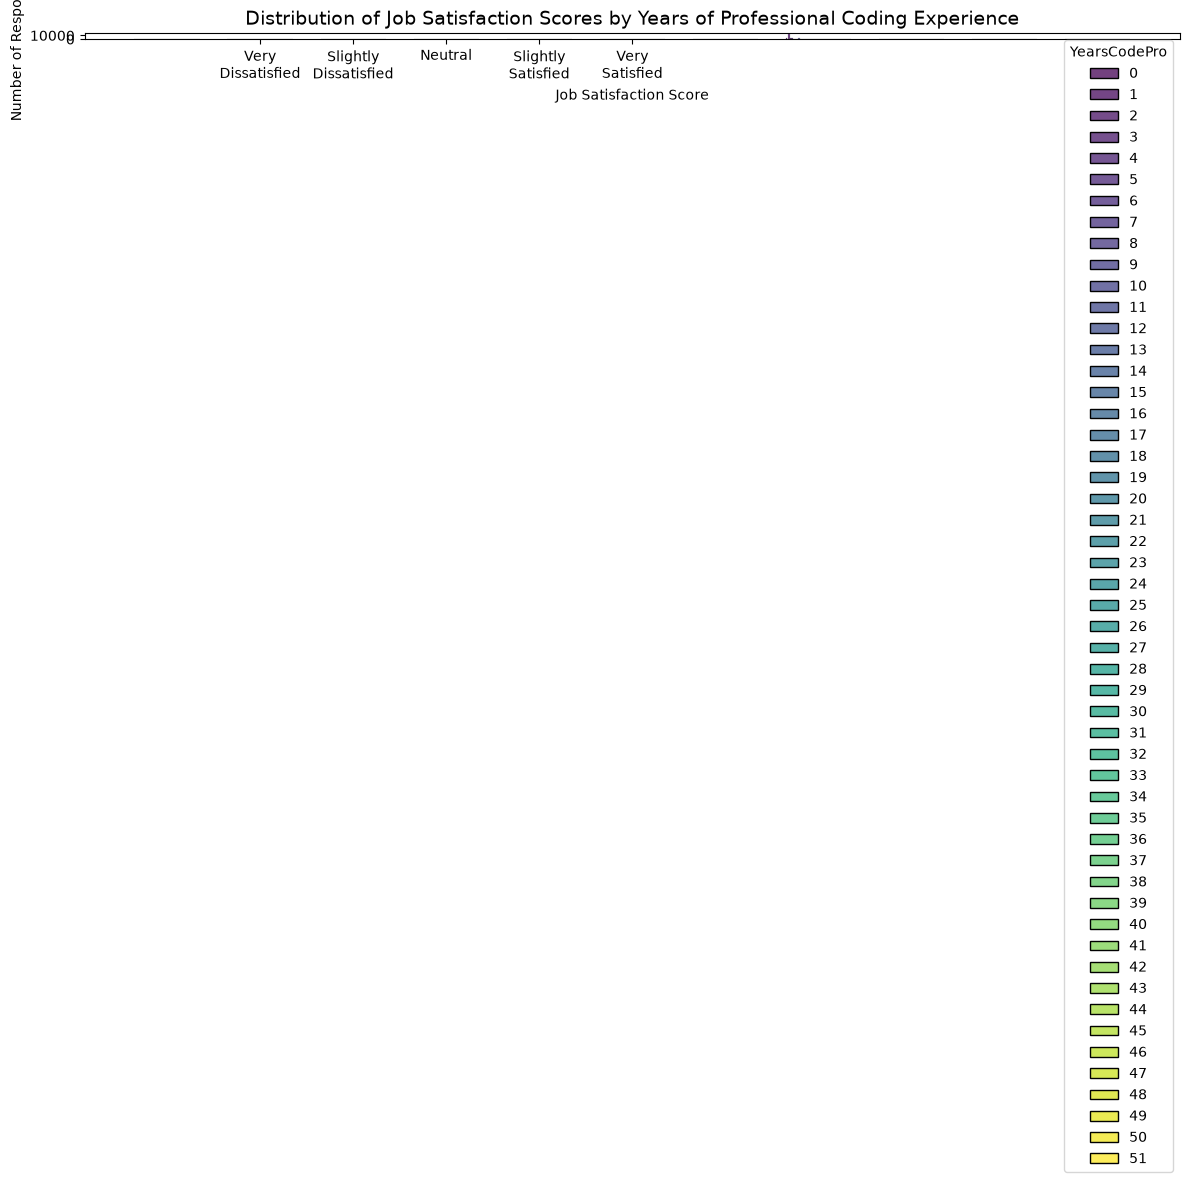

In [30]:
# Write your code here
plt.figure(figsize=(12, 7))

# Plotting directly using your cleaned numeric columns
sns.histplot(
    data=df.dropna(subset=["JobSat", "YearsCodePro"]),
    x="JobSat",
    hue="YearsCodePro",
    multiple="dodge",
    discrete=True,
    shrink=0.7,
    palette="viridis",
    edgecolor="black",
)

plt.title(
    "Distribution of Job Satisfaction Scores by Years of Professional Coding Experience",
    fontsize=14,
)
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Respondents")

# FIXED: Explicitly added the 1-5 coordinate points for the labels
plt.xticks(
    ticks=[1, 2, 3, 4, 5],
    labels=[
        "Very\nDissatisfied",
        "Slightly\nDissatisfied",
        "Neutral",
        "Slightly\nSatisfied",
        "Very\nSatisfied",
    ],
)

plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
